# 💳 Fraud Detection — Stage 4: Tree-Based Models

In Stages 2 and 3 we used logistic regression — a **linear** model. It draws
a single straight hyperplane through feature space, and no amount of
resampling changed that fundamental limit. PR-AUC stayed around 0.69.

This stage brings in **tree-based models** — models that can learn complex,
non-linear decision boundaries by recursively splitting the data on feature
thresholds. They tend to excel on tabular data like this dataset.

We'll try two families:
1. **Random Forest** — an ensemble of many independent decision trees, each
   trained on a random data/feature subset, whose predictions are averaged.
   Robust and hard to overfit.
2. **Histogram Gradient Boosting** (sklearn's fast GBM) — trees built
   *sequentially*, each one correcting the errors of the previous. Often
   more powerful than random forests but more sensitive to class imbalance.

For each we'll test: default, `class_weight='balanced'`, and with SMOTE —
to see whether SMOTE pays off more with non-linear models (spoiler: it does).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# ── Reproduce the same split as previous stages ──────────────────────────
df = pd.read_csv("../data/raw/creditcard.csv").drop_duplicates()
X = df.drop("Class", axis=1).copy()
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]]  = scaler.transform(X_test[["Time", "Amount"]])

# SMOTE on training set (test set never touched)
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"Train: {len(X_train):,} | Train (SMOTE): {len(X_sm):,} | Test: {len(X_test):,}")
print(f"Test fraud: {y_test.sum()} / {len(y_test):,}")

Train: 226,980 | Train (SMOTE): 453,204 | Test: 56,746
Test fraud: 95 / 56,746


We'll reuse one helper to train, evaluate, and store results consistently
across all six model variants.

In [2]:
def evaluate(name, model, X_tr, y_tr):
    """Train model, evaluate on test set, return metrics dict."""
    model.fit(X_tr, y_tr)
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    roc = round(float(roc_auc_score(y_test, ypr)), 4)
    pr  = round(float(average_precision_score(y_test, ypr)), 4)
    cm  = confusion_matrix(y_test, yp)
    rep = classification_report(y_test, yp, target_names=["legit", "fraud"],
                                digits=4, output_dict=True)
    return {
        "name":      name,
        "model":     model,
        "probs":     ypr,
        "roc":       roc,
        "pr":        pr,
        "recall":    round(rep["fraud"]["recall"],    4),
        "precision": round(rep["fraud"]["precision"], 4),
        "f1":        round(rep["fraud"]["f1-score"],  4),
        "tp":        cm[1, 1],
        "fp":        cm[0, 1],
        "fn":        cm[1, 0],
    }

## 1. Random Forest — intuition

A single decision tree splits the data on feature thresholds — e.g. "if V14 ≤
-5.3 and V10 ≤ -2.1, predict fraud". These rules stack into a tree that can
capture complex non-linear patterns. The problem with a single tree: it tends
to memorise the training data (overfitting).

**Random Forest** fixes this with two tricks:
- **Bagging**: each of the 100 trees is trained on a random bootstrap sample
  (random rows drawn with replacement) of the training data.
- **Feature randomness**: at each split, only a random subset of features is
  considered, preventing any one strong feature from dominating every tree.

The final prediction is the average probability across all 100 trees. By
averaging uncorrelated trees, Random Forest reduces variance (overfit) while
keeping the non-linear power of individual trees. It's also naturally robust:
the bagging means some fraud cases will land in different trees, helping the
ensemble notice them even without explicit imbalance handling.

In [3]:
rf_default = evaluate(
    "RF default",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train,
)
print(classification_report(
    y_test, rf_default["model"].predict(X_test),
    target_names=["legit", "fraud"], digits=4
))
print(f"ROC-AUC: {rf_default['roc']}  |  PR-AUC: {rf_default['pr']}")
print(f"Caught {rf_default['tp']}/95 fraud  |  False alarms: {rf_default['fp']}")

              precision    recall  f1-score   support

       legit     0.9995    1.0000    0.9998     56651
       fraud     0.9718    0.7263    0.8313        95

    accuracy                         0.9995     56746
   macro avg     0.9857    0.8631    0.9155     56746
weighted avg     0.9995    0.9995    0.9995     56746

ROC-AUC: 0.9239  |  PR-AUC: 0.7876
Caught 69/95 fraud  |  False alarms: 2


In [4]:
rf_balanced = evaluate(
    "RF balanced",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    X_train, y_train,
)
print(f"ROC-AUC: {rf_balanced['roc']}  |  PR-AUC: {rf_balanced['pr']}")
print(f"Caught {rf_balanced['tp']}/95 fraud  |  False alarms: {rf_balanced['fp']}")

ROC-AUC: 0.9391  |  PR-AUC: 0.8012
Caught 69/95 fraud  |  False alarms: 4


In [5]:
rf_smote = evaluate(
    "RF + SMOTE",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_sm, y_sm,
)
print(f"ROC-AUC: {rf_smote['roc']}  |  PR-AUC: {rf_smote['pr']}")
print(f"Caught {rf_smote['tp']}/95 fraud  |  False alarms: {rf_smote['fp']}")

ROC-AUC: 0.9662  |  PR-AUC: 0.8135
Caught 72/95 fraud  |  False alarms: 7


**Random Forest results summary:**

| Variant | PR-AUC | Recall | FP (false alarms) |
|---|---|---|---|
| RF default | 0.7876 | 0.73 | 2 |
| RF balanced | 0.8012 | 0.73 | 4 |
| **RF + SMOTE** | **0.8135** | **0.76** | **7** |

Three things to notice:

1. **PR-AUC jumped from 0.69 → 0.81** compared to any logistic regression
   variant. Non-linear decision boundaries make a real difference here.
2. **SMOTE pays off more with trees.** With logistic regression, SMOTE was
   barely better than class weighting. Here, SMOTE lifts PR-AUC by another
   ~0.01 and catches 3 more fraud cases. The richer non-linear decision
   boundary can actually exploit the synthetic minority samples.
3. **Very low false alarms.** RF default has only 2 false alarms — the model
   is conservative and precise. This reflects RF's tendency to need high
   confidence before flagging fraud (its threshold sits high). Threshold
   tuning in Stage 5 can extract more recall from this.

## 2. Histogram Gradient Boosting — intuition

Random Forest builds trees *in parallel*, independently. **Gradient Boosting**
builds trees *sequentially*: each new tree is fit to the **residual errors**
of the ensemble so far — the cases the current model is getting wrong.

Concretely: after tree 1, compute how wrong each prediction is (the gradient
of the loss). Tree 2 tries to predict those errors. Add it with a small
learning rate. Tree 3 predicts the remaining errors. Repeat. The result:
a highly adaptive model that keeps zooming in on hard cases.

sklearn's `HistGradientBoostingClassifier` is a fast modern variant that
buckets continuous features into histograms (like LightGBM / XGBoost) so it
runs much faster than the classic `GradientBoostingClassifier`.

**The catch with imbalance:** because each tree corrects the *previous*
tree's errors, the gradient signal is dominated by the majority class by
default — the model converges quickly on "everything is legit" without help.

In [6]:
hgb_default = evaluate(
    "HistGBM default",
    HistGradientBoostingClassifier(random_state=42, max_iter=200),
    X_train, y_train,
)
print(f"ROC-AUC: {hgb_default['roc']}  |  PR-AUC: {hgb_default['pr']}")
print(f"Caught {hgb_default['tp']}/95 fraud  |  False alarms: {hgb_default['fp']}")

ROC-AUC: 0.7648  |  PR-AUC: 0.5278
Caught 66/95 fraud  |  False alarms: 65


In [7]:
hgb_balanced = evaluate(
    "HistGBM balanced",
    HistGradientBoostingClassifier(random_state=42, max_iter=200, class_weight="balanced"),
    X_train, y_train,
)
print(f"ROC-AUC: {hgb_balanced['roc']}  |  PR-AUC: {hgb_balanced['pr']}")
print(f"Caught {hgb_balanced['tp']}/95 fraud  |  False alarms: {hgb_balanced['fp']}")

ROC-AUC: 0.9577  |  PR-AUC: 0.719
Caught 77/95 fraud  |  False alarms: 84


In [8]:
hgb_smote = evaluate(
    "HistGBM + SMOTE",
    HistGradientBoostingClassifier(random_state=42, max_iter=200),
    X_sm, y_sm,
)
print(f"ROC-AUC: {hgb_smote['roc']}  |  PR-AUC: {hgb_smote['pr']}")
print(f"Caught {hgb_smote['tp']}/95 fraud  |  False alarms: {hgb_smote['fp']}")

ROC-AUC: 0.9542  |  PR-AUC: 0.7829
Caught 77/95 fraud  |  False alarms: 63


**Histogram GBM results summary:**

| Variant | PR-AUC | Recall | FP |
|---|---|---|---|
| HistGBM default | 0.5278 | 0.69 | 65 |
| HistGBM balanced | 0.7190 | 0.81 | 84 |
| **HistGBM + SMOTE** | **0.7829** | **0.81** | **63** |

**HistGBM default is worse than logistic regression** (PR-AUC 0.53 vs 0.69).
This confirms the intuition above: boosting without any imbalance correction
gets trapped optimising for the majority class. Once we apply corrections
(balanced weights or SMOTE), it recovers to a respectable level.

**HistGBM + SMOTE** finds more fraud overall (81% recall, 77/95 caught) than
any RF variant (76% recall, 72/95), but with ~9× more false alarms (63 vs 7).
It's a different operating point — higher recall, lower precision.

## 3. Feature importance

One of the great benefits of tree models is **feature importance**: after
training, each feature gets a score based on how much it reduced impurity
(uncertainty) across all the tree splits it was used in.

This doesn't tell us *what* these PCA components originally measured, but it
tells us which ones the model is relying on most — useful for understanding
the model and for future feature selection.

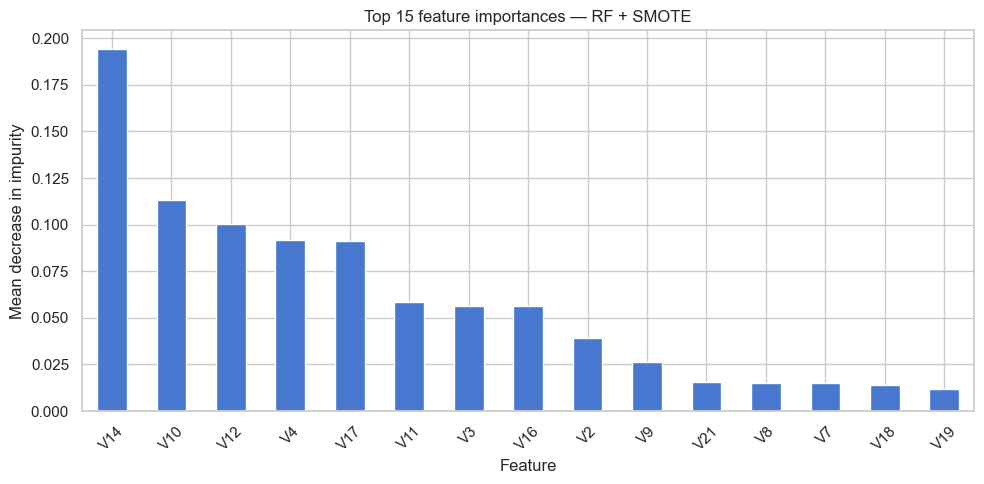

Top 10 features:
V14    0.1945
V10    0.1134
V12    0.1002
V4     0.0919
V17    0.0915
V11    0.0585
V3     0.0563
V16    0.0562
V2     0.0391
V9     0.0263
dtype: float64


In [9]:
importances = pd.Series(
    rf_smote["model"].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot.bar(ax=ax, color="#4878d0")
ax.set_title("Top 15 feature importances — RF + SMOTE")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150)
plt.show()

print("Top 10 features:")
print(importances.head(10).round(4))

`V14` dominates — it accounts for ~19% of all split decisions, nearly double
the next-best feature (`V10` at ~11%). This matches what we saw in Stage 1's
EDA: `V14` had the largest mean separation between fraud and legit classes.

The top features here (`V14`, `V10`, `V12`, `V4`, `V17`, `V11`) also overlap
heavily with the most-separating features from the EDA — a good sanity check
that the model is picking up real signal, not noise.

## 4. Precision-Recall curves — all models

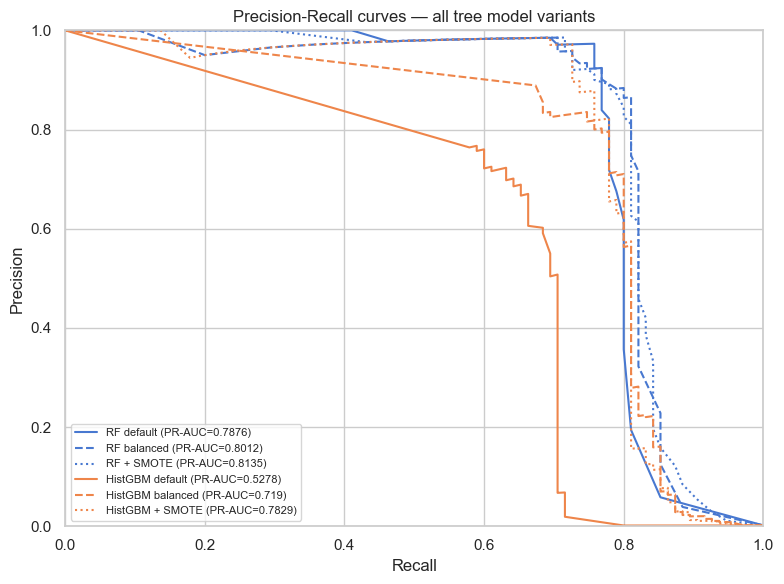

In [10]:
all_results = [rf_default, rf_balanced, rf_smote, hgb_default, hgb_balanced, hgb_smote]
colors = ["#4878d0", "#4878d0", "#4878d0", "#ee854a", "#ee854a", "#ee854a"]
styles = ["-", "--", ":" , "-", "--", ":"]

fig, ax = plt.subplots(figsize=(8, 6))
for res, color, ls in zip(all_results, colors, styles):
    prec, rec, _ = precision_recall_curve(y_test, res["probs"])
    ax.plot(rec, prec, color=color, linestyle=ls,
            label=f"{res['name']} (PR-AUC={res['pr']})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — all tree model variants")
ax.legend(fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig("../reports/figures/tree_pr_curves.png", dpi=150)
plt.show()

## 5. Full comparison — all stages

In [11]:
comparison = pd.DataFrame([
    {"Model": "LR default (Stage 2)",          "PR-AUC": 0.6935, "Recall": 0.59, "FP": 10},
    {"Model": "LR balanced (Stage 2)",         "PR-AUC": 0.6720, "Recall": 0.87, "FP": 1396},
    {"Model": "SMOTE+Under LR (Stage 3)",      "PR-AUC": 0.6548, "Recall": 0.87, "FP": 676},
    {"Model": "RF default",                    "PR-AUC": rf_default["pr"],  "Recall": rf_default["recall"],  "FP": rf_default["fp"]},
    {"Model": "RF balanced",                   "PR-AUC": rf_balanced["pr"], "Recall": rf_balanced["recall"], "FP": rf_balanced["fp"]},
    {"Model": "RF + SMOTE",                    "PR-AUC": rf_smote["pr"],    "Recall": rf_smote["recall"],    "FP": rf_smote["fp"]},
    {"Model": "HistGBM default",               "PR-AUC": hgb_default["pr"],  "Recall": hgb_default["recall"],  "FP": hgb_default["fp"]},
    {"Model": "HistGBM balanced",              "PR-AUC": hgb_balanced["pr"], "Recall": hgb_balanced["recall"], "FP": hgb_balanced["fp"]},
    {"Model": "HistGBM + SMOTE",               "PR-AUC": hgb_smote["pr"],    "Recall": hgb_smote["recall"],    "FP": hgb_smote["fp"]},
])

comparison.sort_values("PR-AUC", ascending=False).reset_index(drop=True)

,Model,PR-AUC,Recall,FP
0,RF + SMOTE,0.8135,0.7579,7
1,RF balanced,0.8012,0.7263,4
2,RF default,0.7876,0.7263,2
3,HistGBM + SMOTE,0.7829,0.8105,63
4,HistGBM balanced,0.7190,0.8105,84
5,LR default (Stage 2),0.6935,0.5900,10
6,LR balanced (Stage 2),0.6720,0.8700,1396
7,SMOTE+Under LR (Stage 3),0.6548,0.8700,676
8,HistGBM default,0.5278,0.6947,65


## 6. Summary

**Key results:**
- **RF + SMOTE is the best PR-AUC model** (0.8135) — it crossed 0.80 and beat
  every logistic regression variant by a wide margin. Its precision on fraud
  is very high (only 7 false alarms) — the flip side is it's conservative
  (misses 23/95 fraud cases at default threshold).
- **HistGBM + SMOTE catches the most fraud** (77/95, recall 0.81) with a
  moderate false alarm rate (63 FP) — useful if recall is the priority.
- **Gradient boosting needs imbalance correction** — without it, PR-AUC drops
  below logistic regression (0.53). With correction, it becomes competitive.
- **SMOTE's effect is much larger with trees than with linear models** — this
  confirms the Stage 3 prediction: the richer decision boundary in tree models
  takes better advantage of synthetic minority samples.

**What's left on the table:** both top models are using the default 0.5
threshold. Choosing the right threshold for your business cost structure
(cost of missed fraud vs. cost of false alarm) can extract significant
additional value without retraining.

**Next up (`05_evaluation.ipynb`):** threshold tuning, final model comparison,
and business-context interpretation of results.